In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
df = pd.read_csv("/content/insurance.csv")

print(df.head())
print("\n", df.info())
print("\n", df.describe())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

 None

                age          bmi     children       charges
count  1338.000000  1338.000

In [6]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

# Fill missing numerical with mean, categorical with mode
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after cleaning:", df.shape)

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Shape after cleaning: (1337, 7)


In [7]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder

# Label encode binary columns only (2 categories, order doesn't matter here)
le = LabelEncoder()
df["sex"]    = le.fit_transform(df["sex"])      # male/female → 1/0
df["smoker"] = le.fit_transform(df["smoker"])   # yes/no → 1/0

# OneHot encode 'region' (4 unordered categories, k-1 rule → drop_first=True)
df = pd.get_dummies(df, columns=["region"], drop_first=True)

# CHANGED: X and y separated here only, NO scaling here anymore
# Scaling moved to Cell 5 to avoid data leakage
X = df.drop(columns=["charges"])
y = df["charges"]

print("Columns after encoding:", list(df.columns))
print("X shape:", X.shape)

Columns after encoding: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']
X shape: (1337, 8)


In [8]:
# Split BEFORE scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# CHANGED: fit_transform on train only, transform only on test
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print(f"Intercept    : {model.intercept_:.2f}")
print(f"Coefficients : {model.coef_}")

Intercept    : -1538.38
Coefficients : [11417.69313034  -101.54205399 11846.1325602   2665.04994399
 23077.76459287  -391.76145478  -838.91961573  -659.13975155]


In [9]:
# CHANGED: using X_test_scaled instead of X_test
y_pred = model.predict(X_test_scaled)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MSE  : 35478020.68
RMSE : 5956.34
R²   : 0.8069


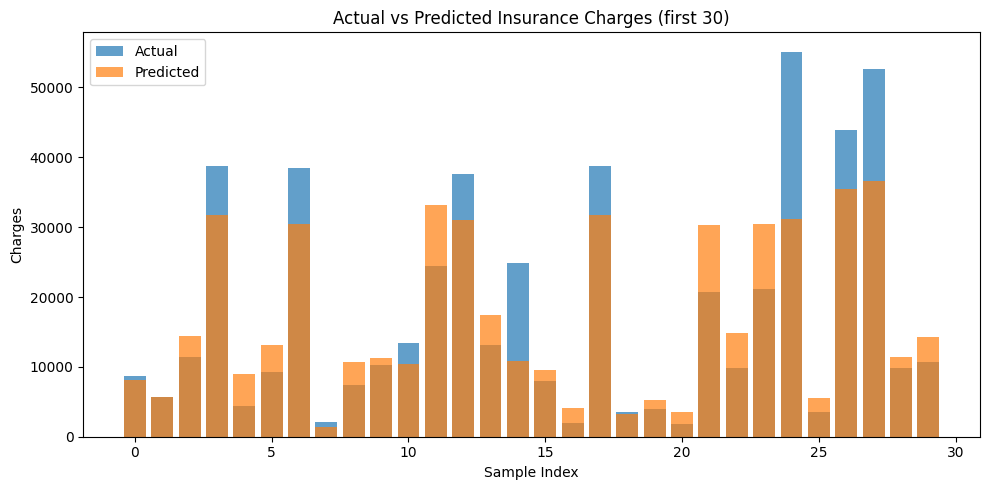

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(range(len(y_test[:30])), y_test[:30], label="Actual", alpha=0.7)
plt.bar(range(len(y_pred[:30])), y_pred[:30], label="Predicted", alpha=0.7)
plt.title("Actual vs Predicted Insurance Charges (first 30)")
plt.xlabel("Sample Index")
plt.ylabel("Charges")
plt.legend()
plt.tight_layout()
plt.show()

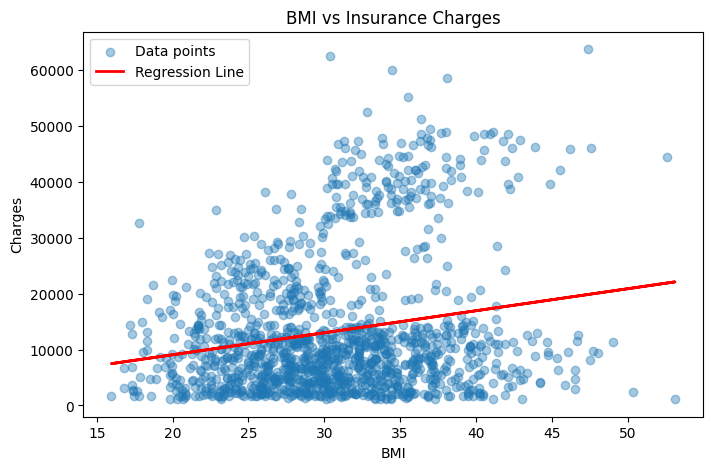

In [11]:
# Use raw BMI column for single-feature regression line plot
X_bmi = df[["bmi"]]
y_charges = df["charges"]

simple_model = LinearRegression()
simple_model.fit(X_bmi, y_charges)
y_line = simple_model.predict(X_bmi)

plt.figure(figsize=(8, 5))
plt.scatter(df["bmi"], y_charges, alpha=0.4, label="Data points")
plt.plot(df["bmi"], y_line, color="red", linewidth=2, label="Regression Line")
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.legend()
plt.show()

Gradient Descent → slope: 2402.71, intercept: 13279.12


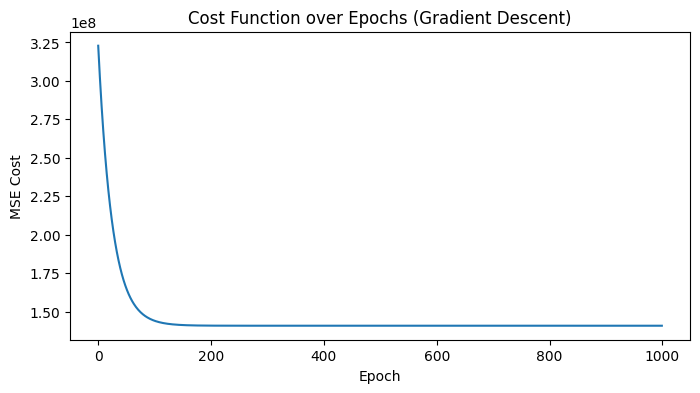

In [12]:
# Normalize BMI for gradient descent stability
x_gd = (df["bmi"] - df["bmi"].mean()) / df["bmi"].std()
y_gd = df["charges"].values

def gradient_descent(x, y, lr=0.01, epochs=1000):
    n = len(x)
    m = 0  # slope
    b = 0  # intercept
    costs = []

    for _ in range(epochs):
        y_pred = m * x + b
        error  = y - y_pred
        cost   = (error ** 2).mean()
        costs.append(cost)

        m_grad = -(2/n) * sum(x * error)
        b_grad = -(2/n) * sum(error)

        m -= lr * m_grad
        b -= lr * b_grad

    return m, b, costs

m, b, costs = gradient_descent(x_gd.values, y_gd, lr=0.01, epochs=1000)
print(f"Gradient Descent → slope: {m:.2f}, intercept: {b:.2f}")

# Plot cost over epochs
plt.figure(figsize=(8, 4))
plt.plot(costs)
plt.title("Cost Function over Epochs (Gradient Descent)")
plt.xlabel("Epoch")
plt.ylabel("MSE Cost")
plt.show()

TASK 2 — Salary Prediction

In [15]:
sal = pd.read_csv("/content/salary_dataset.csv")

print(sal.head())
print(sal.isnull().sum())
print(sal.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/salary_dataset.csv'

In [17]:
sal = pd.read_csv("/content/Salary_dataset.csv")  # changed filename

print(sal.head())
print(sal.isnull().sum())
print(sal.shape)

   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64
(30, 3)


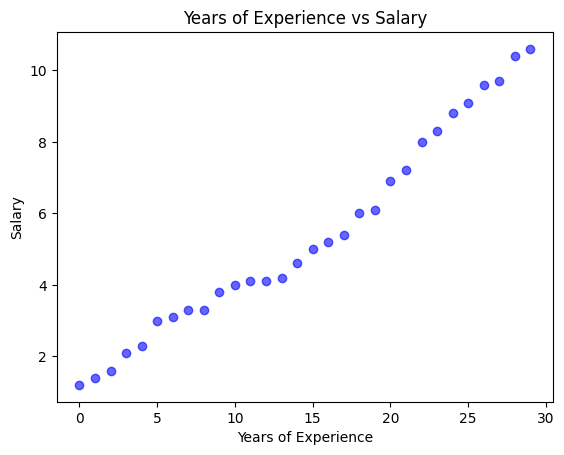

In [18]:
# Scatter plot of the dataset
# sal.iloc[:, 0] -> Select ALL rows (:) from column index 0 (Years of Experience)
# sal.iloc[:, 1] -> Select ALL rows (:) from column index 1 (Salary)
# General syntax: DataFrame.iloc[row_selection, column_selection]
plt.scatter(sal.iloc[:, 0], sal.iloc[:, 1], color="blue", alpha=0.6)

# Add title and axis labels
plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

# Display the plot
plt.show()


# Extract the feature (independent variable)
# iloc[:, 0]
#   :  -> select every row
#   0  -> select the first column
# .values converts the pandas Series into a NumPy array
# reshape(-1, 1) converts shape from (n,) to (n, 1),
# which is required by scikit-learn for input features
X_sal = sal.iloc[:, 0].values.reshape(-1, 1)

# Extract the target (dependent variable)
# iloc[:, 1]
#   :  -> select every row
#   1  -> select the second column (Salary)
y_sal = sal.iloc[:, 1].values



X_tr, X_te, y_tr, y_te = train_test_split(
    X_sal,
    y_sal,
    test_size=0.2,
    random_state=42
)

Slope     : 0.32
Intercept : 0.85
MSE       : 0.20
RMSE      : 0.45


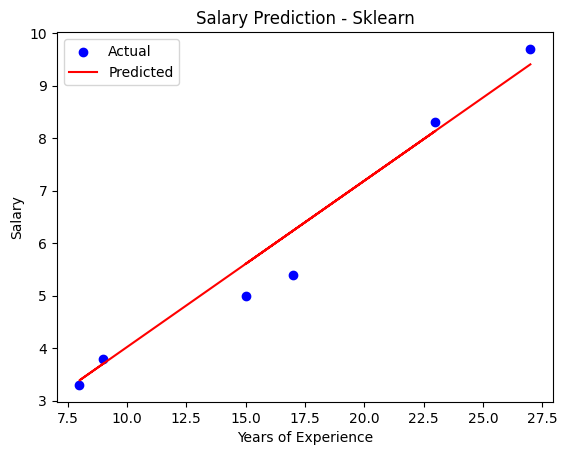

In [20]:
# Create a Linear Regression model object
sal_model = LinearRegression()

# Train (fit) the model using the training data
# The model learns the best-fit line:
# Salary = (Slope × Years_of_Experience) + Intercept
sal_model.fit(X_tr, y_tr)

# Use the trained model to predict salaries for the test dataset
y_sal_pred = sal_model.predict(X_te)


# Display the learned parameters and model performance metrics

# coef_[0] -> slope (coefficient) of the regression line
# Indicates how much salary is expected to increase
# for each additional year of experience
print(f"Slope     : {sal_model.coef_[0]:.2f}")

# intercept_ -> value of salary when Years of Experience = 0
print(f"Intercept : {sal_model.intercept_:.2f}")

# Mean Squared Error (MSE)
# Average of squared differences between actual and predicted salaries
# Lower MSE indicates better model performance
print(f"MSE       : {mean_squared_error(y_te, y_sal_pred):.2f}")

# Root Mean Squared Error (RMSE)
# Square root of MSE, expressed in the same units as Salary
# Easier to interpret than MSE
print(f"RMSE      : {np.sqrt(mean_squared_error(y_te, y_sal_pred)):.2f}")


# Visualize actual test data points
plt.scatter(
    X_te,          # Years of Experience (test set)
    y_te,          # Actual salaries
    color="blue",
    label="Actual"
)

# Plot the regression line (predicted salaries)
plt.plot(
    X_te,
    y_sal_pred,
    color="red",
    label="Predicted"
)

# Add chart title and axis labels
plt.title("Salary Prediction - Sklearn")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

# Display legend and plot
plt.legend()
plt.show()

Gradient Descent → slope: 2.80, intercept: 5.41

Sklearn    intercept: 0.85
Grad Desc  intercept: 5.41


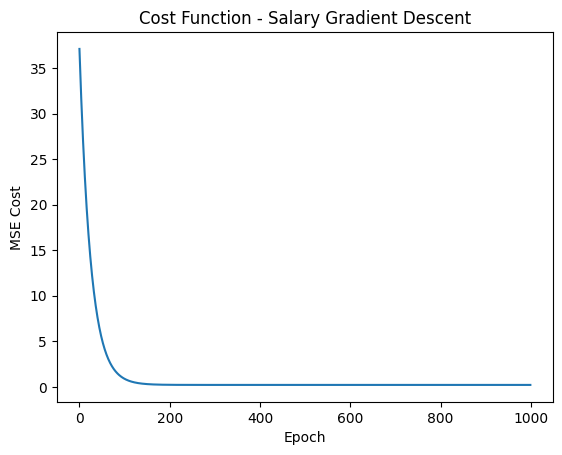

In [21]:
# Normalize for stable gradient descent
x_s = (sal.iloc[:, 0].values - sal.iloc[:, 0].mean()) / sal.iloc[:, 0].std()
y_s = sal.iloc[:, 1].values

m_s, b_s, costs_s = gradient_descent(x_s, y_s, lr=0.01, epochs=1000)

print(f"Gradient Descent → slope: {m_s:.2f}, intercept: {b_s:.2f}")

# Compare sklearn vs gradient descent
print(f"\nSklearn    intercept: {sal_model.intercept_:.2f}")
print(f"Grad Desc  intercept: {b_s:.2f}")

plt.plot(costs_s)
plt.title("Cost Function - Salary Gradient Descent")
plt.xlabel("Epoch")
plt.ylabel("MSE Cost")
plt.show()


# ==========================================
# Explanation
# ==========================================
#
# sal.iloc[:, 0]
#   :  -> select all rows
#   0  -> select the first column (Years of Experience)
#
# x_s stores the normalized feature values using:
#     (x - mean) / standard deviation
#
# Normalization helps Gradient Descent:
# - converge faster
# - avoid very large updates
# - improve numerical stability
#
# y_s contains the target values (Salary).
#
# gradient_descent(...)
# - lr=0.01 controls how large each parameter update is
# - epochs=1000 means the algorithm performs 1000 iterations
#
# Returned values:
# - m_s      -> learned slope (weight)
# - b_s      -> learned intercept (bias)
# - costs_s  -> MSE cost recorded after each epoch
#
# The intercept from Gradient Descent may differ from sklearn's
# intercept because Gradient Descent was trained on normalized
# feature values while sklearn was trained on the original values.
#
# The cost plot shows how the error changes over time.
# A decreasing curve indicates that the model is learning and
# moving toward the optimal solution.